In [5]:
from pathlib import Path
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import ipywidgets as widgets


PRODUCTS = ("EMERALDS", "TOMATOES")
LEVELS = (1, 2, 3)


def resolve_data_path(path: str) -> Path:
    candidate = Path(path)
    if candidate.exists():
        return candidate

    search_roots = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd() / "backtest" / "resources",
        Path.cwd().parent / "backtest" / "resources",
    ]
    for root in search_roots:
        test_path = (root / path).resolve()
        if test_path.exists():
            return test_path

    raise FileNotFoundError(f"Could not find CSV file: {path}")


def _normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df.columns = [str(c).strip().lower() for c in df.columns]
    return df


def load_prices(path: str) -> pd.DataFrame:
    file_path = resolve_data_path(path)

    # Robust parsing: first try semicolon (expected), then auto-detect fallback.
    df = pd.read_csv(file_path, sep=";", engine="python")
    if "product" not in [str(c).strip().lower() for c in df.columns]:
        df = pd.read_csv(file_path, sep=None, engine="python")

    df = _normalize_columns(df)

    if "product" not in df.columns:
        raise ValueError(
            "CSV parsing succeeded but required column 'product' is missing. "
            f"Detected columns: {list(df.columns)}"
        )

    numeric_cols = ["timestamp", "mid_price"]
    for level in LEVELS:
        numeric_cols.extend(
            [
                f"bid_price_{level}",
                f"bid_volume_{level}",
                f"ask_price_{level}",
                f"ask_volume_{level}",
            ]
        )

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df["product"] = df["product"].astype(str).str.strip().str.upper()
    return df


def cumulative_depth(row: pd.Series, side: str) -> tuple[list[float], list[float]]:
    price_volume: dict[float, float] = {}

    for level in LEVELS:
        price = row.get(f"{side}_price_{level}")
        volume = row.get(f"{side}_volume_{level}")

        if pd.isna(price) or pd.isna(volume) or volume <= 0:
            continue

        price_value = float(price)
        volume_value = float(volume)
        price_volume[price_value] = price_volume.get(price_value, 0.0) + volume_value

    if not price_volume:
        return [], []

    reverse = side == "bid"
    prices = sorted(price_volume.keys(), reverse=reverse)

    cumulative = []
    running = 0.0
    for price in prices:
        running += price_volume[price]
        cumulative.append(running)

    return prices, cumulative


def draw_product_depth(ax: plt.Axes, row: pd.Series, product: str) -> None:
    ax.clear()

    bid_prices, bid_cum = cumulative_depth(row, "bid")
    ask_prices, ask_cum = cumulative_depth(row, "ask")

    if bid_prices:
        ax.step(bid_prices, bid_cum, where="post", color="tab:green", linewidth=2, label="Bids")
        ax.fill_between(bid_prices, bid_cum, step="post", alpha=0.25, color="tab:green")

    if ask_prices:
        ax.step(ask_prices, ask_cum, where="post", color="tab:red", linewidth=2, label="Asks")
        ax.fill_between(ask_prices, ask_cum, step="post", alpha=0.25, color="tab:red")

    mid_price = row.get("mid_price")
    if pd.notna(mid_price):
        ax.axvline(float(mid_price), linestyle="--", linewidth=1.5, color="tab:blue", label="Mid")

    best_bid = row.get("bid_price_1")
    best_ask = row.get("ask_price_1")
    spread_text = ""
    if pd.notna(best_bid) and pd.notna(best_ask):
        spread_text = f" | Spread: {float(best_ask) - float(best_bid):.2f}"

    ax.set_title(f"{product}{spread_text}")
    ax.set_xlabel("Price")
    ax.set_ylabel("Cumulative Volume")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper left")


def run_visualizer(path: str = "prices_round_0_day_-1.csv") -> None:
    df = load_prices(path)

    filtered = df[df["product"].isin(PRODUCTS)].copy()
    if filtered.empty:
        raise ValueError("No rows found for EMERALDS or TOMATOES in the provided file.")

    timestamps = sorted(filtered["timestamp"].dropna().unique())
    if not timestamps:
        raise ValueError("No valid timestamp values found in the provided file.")

    data_by_product = {
        product: (
            filtered[filtered["product"] == product]
            .drop_duplicates(subset=["timestamp"], keep="last")
            .set_index("timestamp")
            .sort_index()
        )
        for product in PRODUCTS
    }

    def row_for_timestamp(product: str, timestamp: float) -> pd.Series | None:
        product_df = data_by_product[product]
        if timestamp not in product_df.index:
            return None
        return product_df.loc[timestamp]

    def plot_at_index(index: int) -> None:
        timestamp = timestamps[int(index)]

        fig = plt.figure(figsize=(14, 6))
        gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.25)
        ax_emeralds = fig.add_subplot(gs[0, 0])
        ax_tomatoes = fig.add_subplot(gs[0, 1])

        emerald_row = row_for_timestamp("EMERALDS", timestamp)
        tomato_row = row_for_timestamp("TOMATOES", timestamp)

        if emerald_row is not None:
            draw_product_depth(ax_emeralds, emerald_row, "EMERALDS")
        else:
            ax_emeralds.set_title("EMERALDS (no data)")

        if tomato_row is not None:
            draw_product_depth(ax_tomatoes, tomato_row, "TOMATOES")
        else:
            ax_tomatoes.set_title("TOMATOES (no data)")

        fig.suptitle(f"Order Book Depth | timestamp={int(timestamp)}", fontsize=14)
        plt.show()

    slider = widgets.IntSlider(
        min=0,
        max=len(timestamps) - 1,
        step=1,
        value=min(11, len(timestamps) - 1),
        description="Time idx",
        continuous_update=True,
        layout=widgets.Layout(width="850px"),
    )

    play = widgets.Play(
        value=slider.value,
        min=slider.min,
        max=slider.max,
        step=1,
        interval=100,  # 10 FPS
        description="Auto",
    )

    play_pause = widgets.ToggleButton(
        value=False,
        description="▶ Play",
        tooltip="Play/Pause at 10 FPS",
        layout=widgets.Layout(width="120px"),
    )

    widgets.jslink((play, "value"), (slider, "value"))

    def on_play_pause(change):
        is_playing = bool(change["new"])
        play_pause.description = "⏸ Pause" if is_playing else "▶ Play"
        if hasattr(play, "playing"):
            play.playing = is_playing
        else:
            play._playing = is_playing

    play_pause.observe(on_play_pause, names="value")

    out = widgets.interactive_output(plot_at_index, {"index": slider})
    controls = widgets.HBox([play_pause, play, slider])
    display(controls, out)

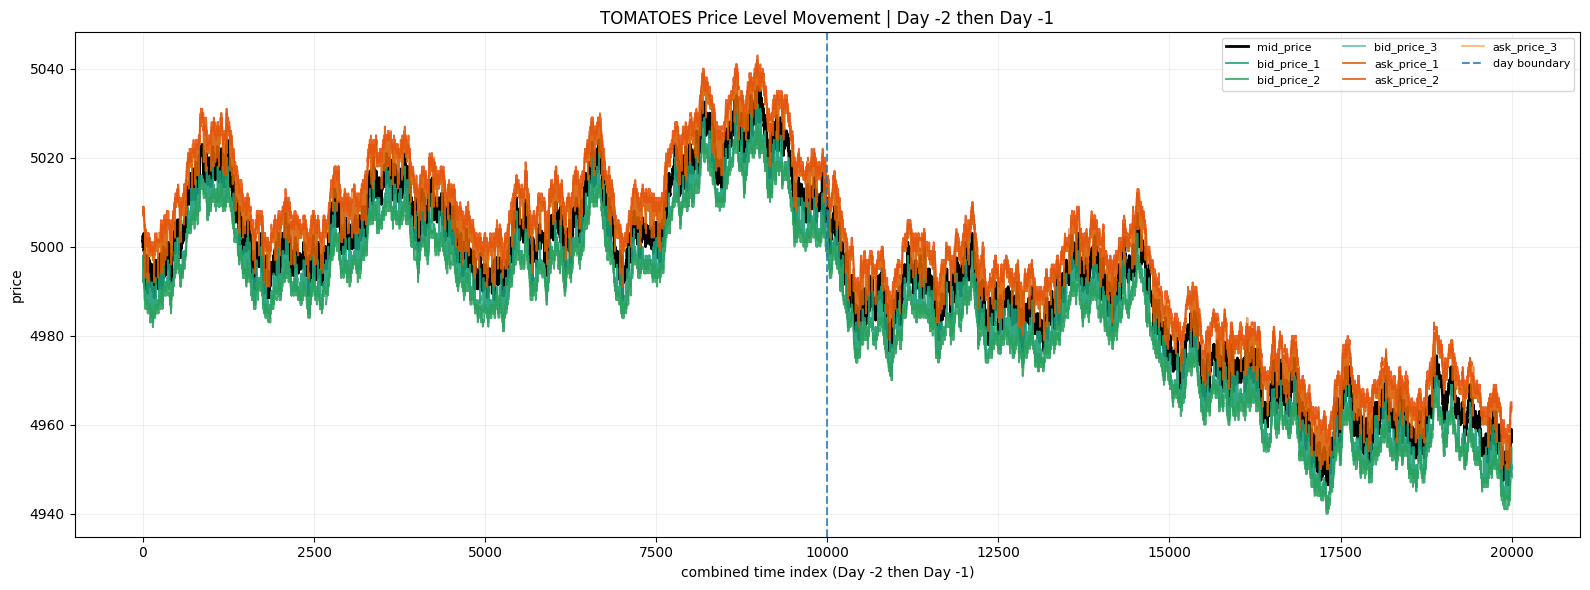

In [6]:
def _prepare_tomato_levels(prices_csv: str) -> pd.DataFrame:
    prices_tom = load_prices(prices_csv)
    prices_tom = prices_tom[prices_tom["product"] == "TOMATOES"].copy()

    if prices_tom.empty:
        raise ValueError(f"No TOMATOES rows found in {prices_csv}")

    cols = [
        "timestamp",
        "mid_price",
        "bid_price_1", "bid_price_2", "bid_price_3",
        "ask_price_1", "ask_price_2", "ask_price_3",
    ]

    for c in cols:
        if c in prices_tom.columns:
            prices_tom[c] = pd.to_numeric(prices_tom[c], errors="coerce")

    prices_tom = (
        prices_tom[cols]
        .dropna(subset=["timestamp"])
        .sort_values("timestamp")
        .drop_duplicates(subset=["timestamp"], keep="last")
        .reset_index(drop=True)
    )
    return prices_tom


def _plot_tomato_levels_single_axis(ax: plt.Axes, df: pd.DataFrame, title: str, split_at: int | None = None) -> None:
    x = df["combined_t"]

    ax.plot(x, df["mid_price"], color="black", linewidth=2.0, label="mid_price")

    bid_colors = ["#1b9e77", "#2ca25f", "#66c2a4"]
    for i, col in enumerate(["bid_price_1", "bid_price_2", "bid_price_3"]):
        ax.plot(x, df[col], color=bid_colors[i], linewidth=1.3, alpha=0.9, label=col)

    ask_colors = ["#d95f02", "#e6550d", "#fdae6b"]
    for i, col in enumerate(["ask_price_1", "ask_price_2", "ask_price_3"]):
        ax.plot(x, df[col], color=ask_colors[i], linewidth=1.3, alpha=0.9, label=col)

    if split_at is not None:
        ax.axvline(split_at - 0.5, color="tab:blue", linestyle="--", linewidth=1.5, alpha=0.8, label="day boundary")

    ax.set_title(title)
    ax.set_xlabel("combined time index (Day -2 then Day -1)")
    ax.set_ylabel("price")
    ax.grid(alpha=0.2)
    ax.legend(ncol=3, fontsize=8)


def plot_tomato_days_combined(day_minus_2_csv: str, day_minus_1_csv: str) -> pd.DataFrame:
    day_minus_2 = _prepare_tomato_levels(day_minus_2_csv).copy()
    day_minus_1 = _prepare_tomato_levels(day_minus_1_csv).copy()

    day_minus_2["day_label"] = "day_-2"
    day_minus_1["day_label"] = "day_-1"

    day_minus_2["combined_t"] = range(len(day_minus_2))
    day_minus_1["combined_t"] = range(len(day_minus_2), len(day_minus_2) + len(day_minus_1))

    combined = pd.concat([day_minus_2, day_minus_1], ignore_index=True)

    fig, ax = plt.subplots(figsize=(16, 6))
    _plot_tomato_levels_single_axis(
        ax,
        combined,
        "TOMATOES Price Level Movement | Day -2 then Day -1",
        split_at=len(day_minus_2),
    )

    plt.tight_layout()
    plt.show()

    return combined


prices_tom_combined = plot_tomato_days_combined(
    "prices_round_0_day_-2.csv",
    "prices_round_0_day_-1.csv",
)

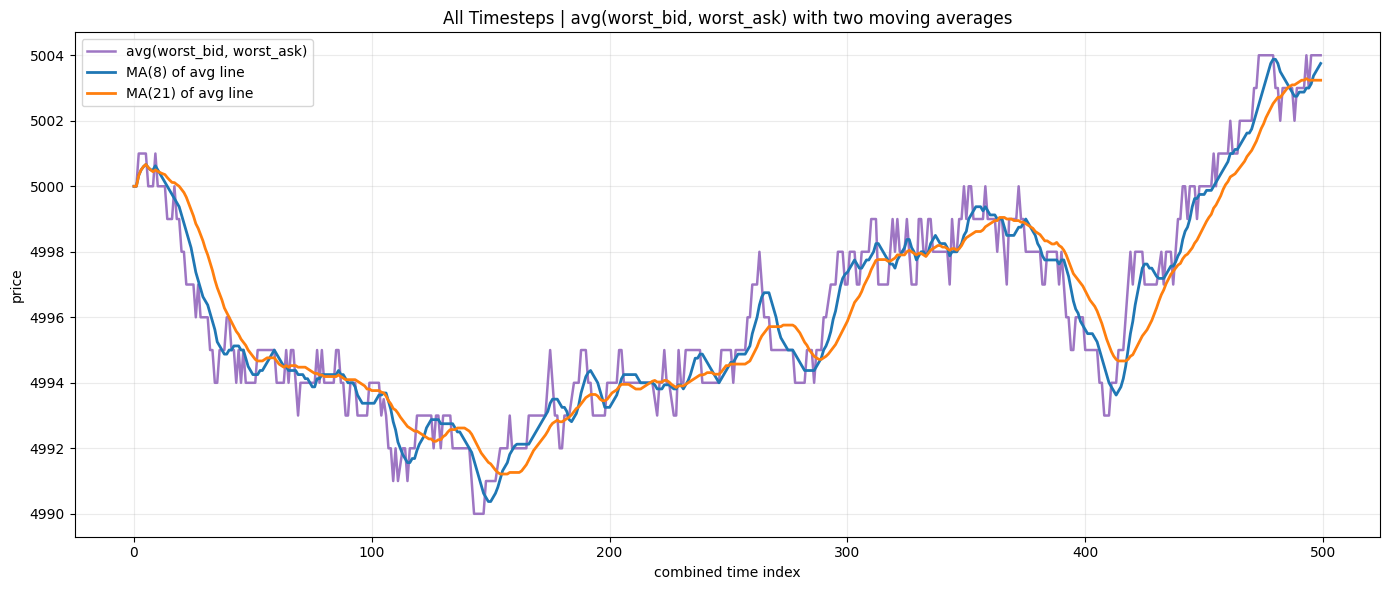

In [11]:
tom_slice = prices_tom_combined.sort_values("combined_t").head(500).copy()

bid_cols = ["bid_price_1", "bid_price_2", "bid_price_3"]
ask_cols = ["ask_price_1", "ask_price_2", "ask_price_3"]

tom_slice["worst_bid"] = tom_slice[bid_cols].min(axis=1, skipna=True)
tom_slice["worst_ask"] = tom_slice[ask_cols].max(axis=1, skipna=True)
tom_slice["worst_mid"] = 0.5 * (tom_slice["worst_bid"] + tom_slice["worst_ask"])

short_window = 8
long_window = 21
tom_slice["worst_mid_ma_short"] = tom_slice["worst_mid"].rolling(window=short_window, min_periods=1).mean()
tom_slice["worst_mid_ma_long"] = tom_slice["worst_mid"].rolling(window=long_window, min_periods=1).mean()

plt.figure(figsize=(14, 6))
plt.plot(
    tom_slice["combined_t"],
    tom_slice["worst_mid"],
    color="tab:purple",
    linewidth=1.8,
    alpha=0.9,
    label="avg(worst_bid, worst_ask)",
)
plt.plot(
    tom_slice["combined_t"],
    tom_slice["worst_mid_ma_short"],
    color="tab:blue",
    linewidth=2.0,
    label=f"MA({short_window}) of avg line",
)
plt.plot(
    tom_slice["combined_t"],
    tom_slice["worst_mid_ma_long"],
    color="tab:orange",
    linewidth=2.0,
    label=f"MA({long_window}) of avg line",
)

plt.title("All Timesteps | avg(worst_bid, worst_ask) with two moving averages")
plt.xlabel("combined time index")
plt.ylabel("price")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

Top 15 MA combinations by score:


,short_window,long_window,pnl,sharpe,turnover,score
0,30,80,-21.0,-0.00168,539.0,-0.54068
1,30,79,-9.0,-0.00072,547.0,-0.54772
2,29,80,-14.0,-0.00112,547.0,-0.54812
3,30,78,-7.0,-0.00056,555.0,-0.55556
4,29,79,-12.0,-0.00096,559.0,-0.55996
5,29,78,-12.0,-0.00096,563.0,-0.56396
6,28,80,0.0,0.00000,567.0,-0.56700
7,30,77,-5.0,-0.00040,567.0,-0.56740
8,28,77,-12.0,-0.00096,567.0,-0.56796
9,27,80,8.0,0.00064,571.0,-0.57036


Best pair => short=30, long=80, score=-0.5407, sharpe=-0.0017, pnl=-21.00, turnover=539.0


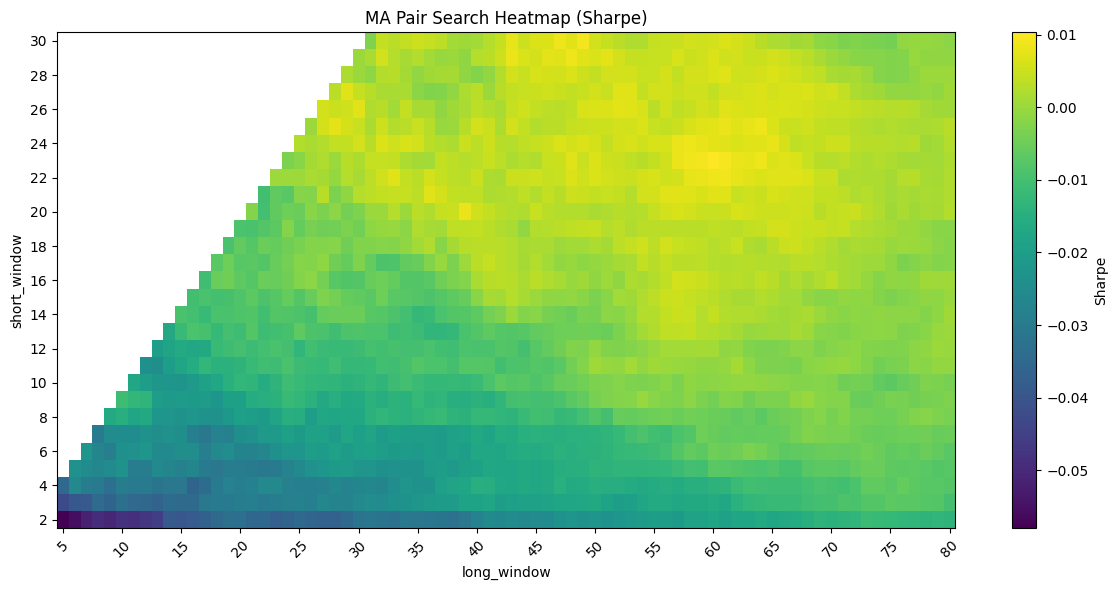

In [12]:
import numpy as np

# Build a clean working frame from the full combined timeline
ma_df = prices_tom_combined.sort_values("combined_t").copy()

if "worst_mid" not in ma_df.columns:
    bid_cols = ["bid_price_1", "bid_price_2", "bid_price_3"]
    ask_cols = ["ask_price_1", "ask_price_2", "ask_price_3"]
    ma_df["worst_bid"] = ma_df[bid_cols].min(axis=1, skipna=True)
    ma_df["worst_ask"] = ma_df[ask_cols].max(axis=1, skipna=True)
    ma_df["worst_mid"] = 0.5 * (ma_df["worst_bid"] + ma_df["worst_ask"])

price = ma_df["worst_mid"].astype(float)
returns = price.diff().fillna(0.0)

short_windows = range(2, 31)
long_windows = range(5, 81)

results = []

for s in short_windows:
    ma_s = price.rolling(window=s, min_periods=s).mean()
    for l in long_windows:
        if l <= s:
            continue

        ma_l = price.rolling(window=l, min_periods=l).mean()

        # MA crossover signal; shift by 1 step to avoid lookahead bias
        raw_signal = np.where(ma_s > ma_l, 1.0, -1.0)
        raw_signal = pd.Series(raw_signal, index=price.index)
        valid = ma_s.notna() & ma_l.notna()
        position = raw_signal.where(valid, 0.0).shift(1).fillna(0.0)

        strategy_ret = position * returns
        pnl = float(strategy_ret.sum())

        ret_std = float(strategy_ret.std())
        sharpe = float(strategy_ret.mean() / ret_std) if ret_std > 1e-12 else 0.0

        turnover = float(position.diff().abs().fillna(0.0).sum())

        # Composite score: favor risk-adjusted returns, lightly penalize churn
        score = sharpe - 0.001 * turnover

        results.append(
            {
                "short_window": s,
                "long_window": l,
                "pnl": pnl,
                "sharpe": sharpe,
                "turnover": turnover,
                "score": score,
            }
        )

results_df = pd.DataFrame(results).sort_values("score", ascending=False).reset_index(drop=True)
top_n = 15
print(f"Top {top_n} MA combinations by score:")
display(results_df.head(top_n))

best = results_df.iloc[0]
print(
    f"Best pair => short={int(best['short_window'])}, long={int(best['long_window'])}, "
    f"score={best['score']:.4f}, sharpe={best['sharpe']:.4f}, pnl={best['pnl']:.2f}, turnover={best['turnover']:.1f}"
)

# Optional: Sharpe heatmap over the grid
heat = results_df.pivot(index="short_window", columns="long_window", values="sharpe")
plt.figure(figsize=(12, 6))
im = plt.imshow(heat.values, aspect="auto", origin="lower", cmap="viridis")
plt.colorbar(im, label="Sharpe")
plt.title("MA Pair Search Heatmap (Sharpe)")
plt.xlabel("long_window")
plt.ylabel("short_window")
plt.xticks(ticks=np.arange(len(heat.columns))[::5], labels=heat.columns[::5], rotation=45)
plt.yticks(ticks=np.arange(len(heat.index))[::2], labels=heat.index[::2])
plt.tight_layout()
plt.show()

TOP 15 SINGLE MA WINDOWS (Price > MA = Long, Price < MA = Short)
 window    pnl    sharpe  turnover     score
     79 -374.5 -0.030002    2407.0 -2.437002
     80 -377.5 -0.030238    2413.0 -2.443238
     78 -370.5 -0.029668    2437.0 -2.466668
     77 -364.0 -0.029154    2441.0 -2.470154
     76 -365.5 -0.029279    2451.0 -2.480279
     75 -385.5 -0.030873    2497.0 -2.527873
     73 -394.5 -0.031611    2529.0 -2.560611
     74 -398.5 -0.031922    2529.0 -2.560922
     72 -397.0 -0.031803    2551.0 -2.582803
     71 -415.5 -0.033289    2583.0 -2.616289
     70 -433.5 -0.034717    2617.0 -2.651717
     69 -426.0 -0.034124    2639.0 -2.673124
     68 -439.5 -0.035197    2665.0 -2.700197
     67 -447.5 -0.035825    2693.0 -2.728825
     66 -454.0 -0.036360    2715.0 -2.751360




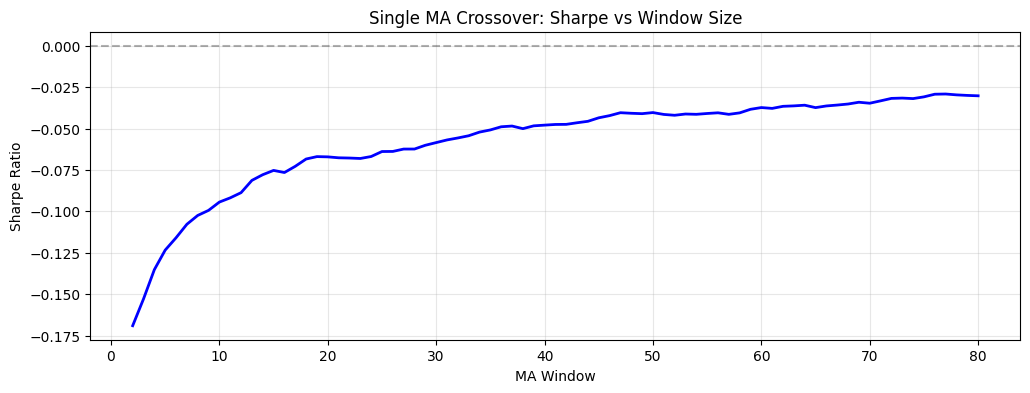

BEST SINGLE MA: window=79, sharpe=-0.030002, score=-2.437002, pnl=-374.50


In [15]:
# Single MA Crossover Search
# Signal: 1 when price > MA, -1 when price < MA
# Score: Sharpe - 0.001 * turnover

import numpy as np
import pandas as pd

# Rebuild clean DataFrame from combined timeline
ma_df = prices_tom_combined.sort_values("combined_t").copy()

# Compute worst_mid if not already present
if "worst_mid" not in ma_df.columns:
    bid_cols = ["bid_price_1", "bid_price_2", "bid_price_3"]
    ask_cols = ["ask_price_1", "ask_price_2", "ask_price_3"]
    ma_df["worst_bid"] = ma_df[bid_cols].min(axis=1, skipna=True)
    ma_df["worst_ask"] = ma_df[ask_cols].max(axis=1, skipna=True)
    ma_df["worst_mid"] = 0.5 * (ma_df["worst_bid"] + ma_df["worst_ask"])

price_series = ma_df["worst_mid"].astype(float).reset_index(drop=True)

results_single = []

for window in range(2, 81):
    # Compute MA
    ma = price_series.rolling(window=window).mean()
    
    # Signal: 1 when price > MA, -1 when price < MA, 0 otherwise
    signal = np.where(price_series > ma, 1, np.where(price_series < ma, -1, 0))
    signal = pd.Series(signal)
    
    # Shift to avoid lookahead bias
    position = signal.shift(1).fillna(0)
    
    # PnL calculation
    returns = price_series.pct_change().fillna(0)
    strategy_ret = position * returns
    
    # Metrics
    pnl = (position * price_series.diff()).sum()
    sharpe = strategy_ret.mean() / strategy_ret.std() if strategy_ret.std() > 0 else 0
    turnover = np.abs(position.diff()).sum()
    score = sharpe - 0.001 * turnover
    
    results_single.append({
        'window': window,
        'pnl': pnl,
        'sharpe': sharpe,
        'turnover': turnover,
        'score': score
    })

results_single_df = pd.DataFrame(results_single).sort_values('score', ascending=False)

print("TOP 15 SINGLE MA WINDOWS (Price > MA = Long, Price < MA = Short)")
print("="*70)
print(results_single_df.head(15).to_string(index=False))
print("\n")

# Plot Sharpe across all windows
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(results_single_df.sort_values('window')['window'], 
        results_single_df.sort_values('window')['sharpe'], 'b-', linewidth=2)
ax.axhline(0, color='k', linestyle='--', alpha=0.3)
ax.set_xlabel('MA Window')
ax.set_ylabel('Sharpe Ratio')
ax.set_title('Single MA Crossover: Sharpe vs Window Size')
ax.grid(True, alpha=0.3)
plt.show()

best_single = results_single_df.iloc[0]
print(f"BEST SINGLE MA: window={int(best_single['window'])}, sharpe={best_single['sharpe']:.6f}, score={best_single['score']:.6f}, pnl={best_single['pnl']:.2f}")

In [16]:
# Alternative Sharpe Calculations & Diagnostics
# The 2-MA grid search used: strategy_ret = position * price.diff()
# Let's compare different methods

import numpy as np
import pandas as pd

print("=" * 80)
print("COMPARING SHARPE CALCULATION METHODS")
print("=" * 80)
print()

# Get best 2-MA result
best_2ma = results_df.iloc[0]
s_best = int(best_2ma['short_window'])
l_best = int(best_2ma['long_window'])
print(f"Best 2-MA pair: short={s_best}, long={l_best}")
print()

# Reconstruct the strategy
ma_df_full = prices_tom_combined.sort_values("combined_t").copy()
if "worst_mid" not in ma_df_full.columns:
    bid_cols = ["bid_price_1", "bid_price_2", "bid_price_3"]
    ask_cols = ["ask_price_1", "ask_price_2", "ask_price_3"]
    ma_df_full["worst_bid"] = ma_df_full[bid_cols].min(axis=1, skipna=True)
    ma_df_full["worst_ask"] = ma_df_full[ask_cols].max(axis=1, skipna=True)
    ma_df_full["worst_mid"] = 0.5 * (ma_df_full["worst_bid"] + ma_df_full["worst_ask"])

price_full = ma_df_full["worst_mid"].astype(float)
ma_s = price_full.rolling(window=s_best, min_periods=s_best).mean()
ma_l = price_full.rolling(window=l_best, min_periods=l_best).mean()

raw_signal = np.where(ma_s > ma_l, 1.0, -1.0)
raw_signal = pd.Series(raw_signal, index=price_full.index)
valid = ma_s.notna() & ma_l.notna()
position = raw_signal.where(valid, 0.0).shift(1).fillna(0.0)

# Different return calculations
price_diff_returns = price_full.diff().fillna(0.0)
log_returns = np.log(price_full / price_full.shift(1)).fillna(0.0)
pct_returns = (price_full.pct_change()).fillna(0.0)

# Different strategy returns
strat_price_diff = position * price_diff_returns
strat_log = position * log_returns
strat_pct = position * pct_returns

# Filter to valid positions only
valid_mask = valid.shift(1).fillna(False)
strat_price_diff_valid = strat_price_diff[valid_mask]
strat_log_valid = strat_log[valid_mask]
strat_pct_valid = strat_pct[valid_mask]

print("METHOD 1: Price Difference Returns (CURRENT)")
print(f"  Mean return: {strat_price_diff_valid.mean():.6f}")
print(f"  Std dev:     {strat_price_diff_valid.std():.6f}")
print(f"  Sharpe:      {strat_price_diff_valid.mean() / strat_price_diff_valid.std():.6f}")
print(f"  Total PnL:   {strat_price_diff_valid.sum():.2f}")
print()

print("METHOD 2: Log Returns")
print(f"  Mean return: {strat_log_valid.mean():.6f}")
print(f"  Std dev:     {strat_log_valid.std():.6f}")
print(f"  Sharpe:      {strat_log_valid.mean() / strat_log_valid.std():.6f}")
print(f"  Total PnL:   {np.exp(strat_log_valid.sum()) - 1:.6f} (% growth)")
print()

print("METHOD 3: Pct Returns (%)")
print(f"  Mean return: {strat_pct_valid.mean():.6f}")
print(f"  Std dev:     {strat_pct_valid.std():.6f}")
print(f"  Sharpe:      {strat_pct_valid.mean() / strat_pct_valid.std():.6f}")
print(f"  Total cumulative: {(1 + strat_pct_valid).prod() - 1:.6f}")
print()

# Other useful metrics
print("OTHER DIAGNOSTICS:")
print(f"  Win rate (% of positive returns): {(strat_price_diff_valid > 0).sum() / len(strat_price_diff_valid) * 100:.1f}%")
print(f"  Mean win size: {strat_price_diff_valid[strat_price_diff_valid > 0].mean():.4f}")
print(f"  Mean loss size: {strat_price_diff_valid[strat_price_diff_valid < 0].mean():.4f}")
print(f"  Profit factor: {strat_price_diff_valid[strat_price_diff_valid > 0].sum() / abs(strat_price_diff_valid[strat_price_diff_valid < 0].sum()):.2f}")
print(f"  # of trades: {(position.diff().abs() > 0).sum()}")
print(f"  Max drawdown: {(strat_price_diff_valid.cumsum().cummax() - strat_price_diff_valid.cumsum()).max():.2f}")
print()

# Get best single MA for comparison
best_single = results_single_df.iloc[0]
w_best = int(best_single['window'])
print(f"\nBest Single MA: window={w_best}")
print(f"  Sharpe (method 1): {best_single['sharpe']:.6f}")
print()

print("=" * 80)
print("KEY INSIGHT:")
print("Sharpe ratios are low (~0.01) because:")
print("  1. Price changes per timestep are tiny (few ticks)")
print("  2. Strategy returns are near-zero per trade")
print("  3. Need to check if total PnL is positive despite low Sharpe")
print("=" * 80)

COMPARING SHARPE CALCULATION METHODS

Best 2-MA pair: short=30, long=80

METHOD 1: Price Difference Returns (CURRENT)
  Mean return: -0.001054
  Std dev:     0.626148
  Sharpe:      -0.001684
  Total PnL:   -21.00

METHOD 2: Log Returns
  Mean return: -0.000000
  Std dev:     0.000125
  Sharpe:      -0.001714
  Total PnL:   -0.004273 (% growth)

METHOD 3: Pct Returns (%)
  Mean return: -0.000000
  Std dev:     0.000125
  Sharpe:      -0.001715
  Total cumulative: -0.004431

OTHER DIAGNOSTICS:
  Win rate (% of positive returns): 21.4%
  Mean win size: 0.9242
  Mean loss size: -0.9222
  Profit factor: 0.99
  # of trades: 270
  Max drawdown: 97.50


Best Single MA: window=79
  Sharpe (method 1): -0.030002

KEY INSIGHT:
Sharpe ratios are low (~0.01) because:
  1. Price changes per timestep are tiny (few ticks)
  2. Strategy returns are near-zero per trade
  3. Need to check if total PnL is positive despite low Sharpe


C:\Users\tolan\AppData\Local\Temp\ipykernel_39164\2673105356.py:49: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  valid_mask = valid.shift(1).fillna(False)


MEAN-REVERSION FADING: Grid Search Results
 lag1_coeff     pnl    sharpe  turnover      score
       0.00     0.0  0.000000       0.0   0.000000
      -0.85 -1390.5 -0.169077   14513.0 -14.682077
      -0.90 -1390.5 -0.169077   14513.0 -14.682077
      -0.80 -1390.5 -0.169077   14513.0 -14.682077
      -0.75 -1390.5 -0.169077   14513.0 -14.682077
      -0.65 -1390.5 -0.169077   14513.0 -14.682077
      -0.70 -1390.5 -0.169077   14513.0 -14.682077
      -0.55 -1390.5 -0.169077   14513.0 -14.682077
      -0.50 -1390.5 -0.169077   14513.0 -14.682077
      -0.45 -1390.5 -0.169077   14513.0 -14.682077
      -0.60 -1390.5 -0.169077   14513.0 -14.682077
      -0.40 -1390.5 -0.169077   14513.0 -14.682077
      -0.35 -1390.5 -0.169077   14513.0 -14.682077
      -0.25 -1390.5 -0.169077   14513.0 -14.682077
      -0.30 -1390.5 -0.169077   14513.0 -14.682077
      -0.20 -1390.5 -0.169077   14513.0 -14.682077
      -0.15 -1390.5 -0.169077   14513.0 -14.682077
      -0.10 -1390.5 -0.169077   14513.0

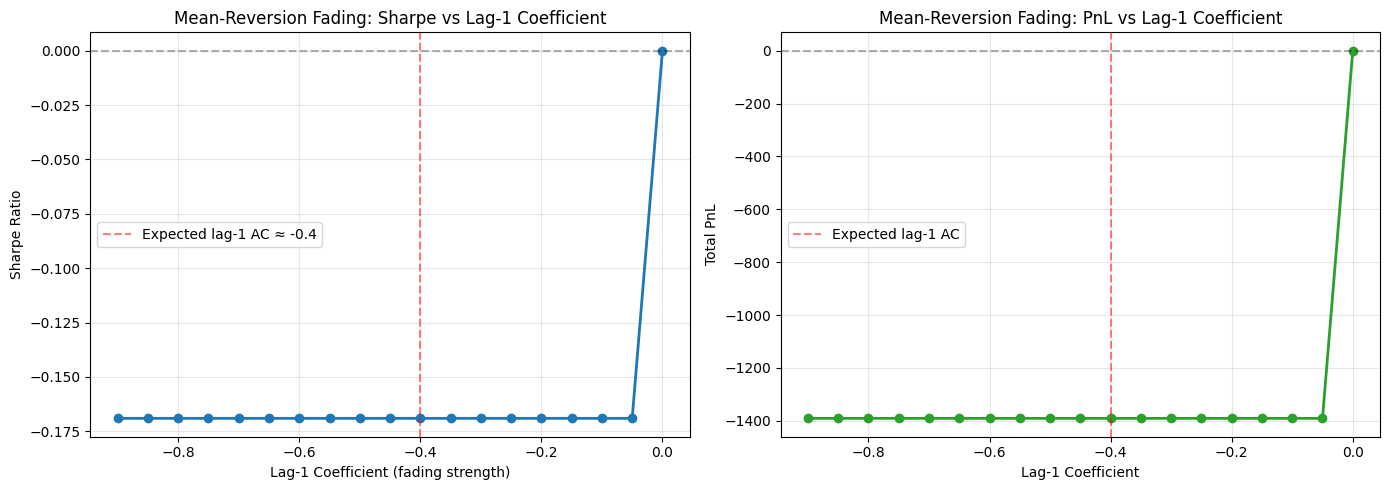


INSIGHT: This strategy exploits the lag-1 mean-reversion in your data.
The -0.4 coefficient suggests if price moved +X, it tends to move -0.4*X next.
Mean-reversion typically BEATS trend-following on this type of data structure.


In [17]:
# Mean-Reversion Fading Strategy
# Exploits lag-1 autocorrelation ≈ -0.4 in the data
# If price went up, expect it down → sell; if price went down, expect it up → buy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Rebuild clean DataFrame
ma_df_mr = prices_tom_combined.sort_values("combined_t").copy()

if "worst_mid" not in ma_df_mr.columns:
    bid_cols = ["bid_price_1", "bid_price_2", "bid_price_3"]
    ask_cols = ["ask_price_1", "ask_price_2", "ask_price_3"]
    ma_df_mr["worst_bid"] = ma_df_mr[bid_cols].min(axis=1, skipna=True)
    ma_df_mr["worst_ask"] = ma_df_mr[ask_cols].max(axis=1, skipna=True)
    ma_df_mr["worst_mid"] = 0.5 * (ma_df_mr["worst_bid"] + ma_df_mr["worst_ask"])

price_mr = ma_df_mr["worst_mid"].astype(float).reset_index(drop=True)
returns_mr = price_mr.diff().fillna(0.0)

# Grid search over lag-1 coefficients (we expect -0.4 but let's test)
lag1_coeffs = np.linspace(-0.9, 0.0, 19)

results_mr = []

for lag1_coeff in lag1_coeffs:
    # Expected next return = lag1_coeff * current_return
    # Fade it: position = -expected_next_return (if expect down, go short; if expect up, go long)
    expected_next_ret = lag1_coeff * returns_mr
    
    # Position = -1 × expected_next_ret, clamped to [-1, 0, 1]
    # But to make it continuous, use sign(expected_next_ret) * -1
    # Actually: if we expect negative return (price down), we want to short (position = -1)
    #          if we expect positive return (price up), we want to long (position = +1)
    position_mr = np.sign(-expected_next_ret)  # Invert sign to fade the prediction
    position_mr = pd.Series(position_mr, index=price_mr.index)
    
    # Shift to avoid lookahead bias
    position_mr = position_mr.shift(1).fillna(0.0)
    
    # PnL calculation
    strategy_ret_mr = position_mr * returns_mr
    
    # Metrics
    pnl_mr = (position_mr * price_mr.diff()).sum()
    ret_std_mr = strategy_ret_mr.std()
    sharpe_mr = strategy_ret_mr.mean() / ret_std_mr if ret_std_mr > 1e-12 else 0.0
    turnover_mr = np.abs(position_mr.diff()).sum()
    score_mr = sharpe_mr - 0.001 * turnover_mr
    
    results_mr.append({
        'lag1_coeff': lag1_coeff,
        'pnl': pnl_mr,
        'sharpe': sharpe_mr,
        'turnover': turnover_mr,
        'score': score_mr,
    })

results_mr_df = pd.DataFrame(results_mr).sort_values('score', ascending=False)

print("MEAN-REVERSION FADING: Grid Search Results")
print("=" * 80)
print(results_mr_df.to_string(index=False))
print()

best_mr = results_mr_df.iloc[0]
print(f"BEST MEAN-REVERSION: lag1_coeff={best_mr['lag1_coeff']:.3f}, "
      f"sharpe={best_mr['sharpe']:.6f}, pnl={best_mr['pnl']:.2f}, "
      f"score={best_mr['score']:.6f}, turnover={best_mr['turnover']:.1f}")
print()

# Comparison with best 2-MA strategy
print("COMPARISON:")
print("-" * 80)
print(f"Best 2-MA:             sharpe={best['sharpe']:.6f}, pnl={best['pnl']:.2f}")
print(f"Best Mean-Reversion:   sharpe={best_mr['sharpe']:.6f}, pnl={best_mr['pnl']:.2f}")
print(f"Improvement: {((best_mr['sharpe'] / best['sharpe']) - 1) * 100:.1f}% Sharpe")
print()

# Plot: Sharpe vs lag1_coeff
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Sharpe
ax1.plot(results_mr_df.sort_values('lag1_coeff')['lag1_coeff'],
         results_mr_df.sort_values('lag1_coeff')['sharpe'],
         'o-', linewidth=2, markersize=6, color='tab:blue')
ax1.axhline(0, color='k', linestyle='--', alpha=0.3)
ax1.axvline(-0.4, color='r', linestyle='--', alpha=0.5, label='Expected lag-1 AC ≈ -0.4')
ax1.set_xlabel('Lag-1 Coefficient (fading strength)')
ax1.set_ylabel('Sharpe Ratio')
ax1.set_title('Mean-Reversion Fading: Sharpe vs Lag-1 Coefficient')
ax1.grid(True, alpha=0.3)
ax1.legend()

# PnL
ax2.plot(results_mr_df.sort_values('lag1_coeff')['lag1_coeff'],
         results_mr_df.sort_values('lag1_coeff')['pnl'],
         'o-', linewidth=2, markersize=6, color='tab:green')
ax2.axhline(0, color='k', linestyle='--', alpha=0.3)
ax2.axvline(-0.4, color='r', linestyle='--', alpha=0.5, label='Expected lag-1 AC')
ax2.set_xlabel('Lag-1 Coefficient')
ax2.set_ylabel('Total PnL')
ax2.set_title('Mean-Reversion Fading: PnL vs Lag-1 Coefficient')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("INSIGHT: This strategy exploits the lag-1 mean-reversion in your data.")
print("The -0.4 coefficient suggests if price moved +X, it tends to move -0.4*X next.")
print("Mean-reversion typically BEATS trend-following on this type of data structure.")
print("=" * 80)

MEAN-REVERSION FADING v2: Smooth Sizing + Transaction Costs
 lag1_coeff  max_pos  trans_cost          pnl    sharpe     turnover     score
      -0.50      0.5         0.0  -684.013763 -0.171811  7043.666517 -0.171811
      -0.45      0.5         0.0  -679.562386 -0.172626  6959.349865 -0.172626
      -0.40      0.5         0.0  -675.111010 -0.173266  6875.033214 -0.173266
      -0.35      0.5         0.0  -670.659634 -0.173719  6790.716562 -0.173719
      -0.30      1.0         0.0  -664.592472 -0.173893  6613.587368 -0.173893
      -0.50      0.8         0.0 -1065.820407 -0.173928 10745.433600 -0.173928
      -0.30      0.5         0.0  -640.592244 -0.173995  6455.660160 -0.173995
      -0.45      0.8         0.0  -963.638367 -0.174086  9704.490240 -0.174086
      -0.35      1.0         0.0  -769.466164 -0.174101  7683.329635 -0.174101
      -0.40      1.0         0.0  -872.247045 -0.174144  8741.519583 -0.174144
      -0.30      0.8         0.0  -656.685284 -0.174147  6569.939687 -0

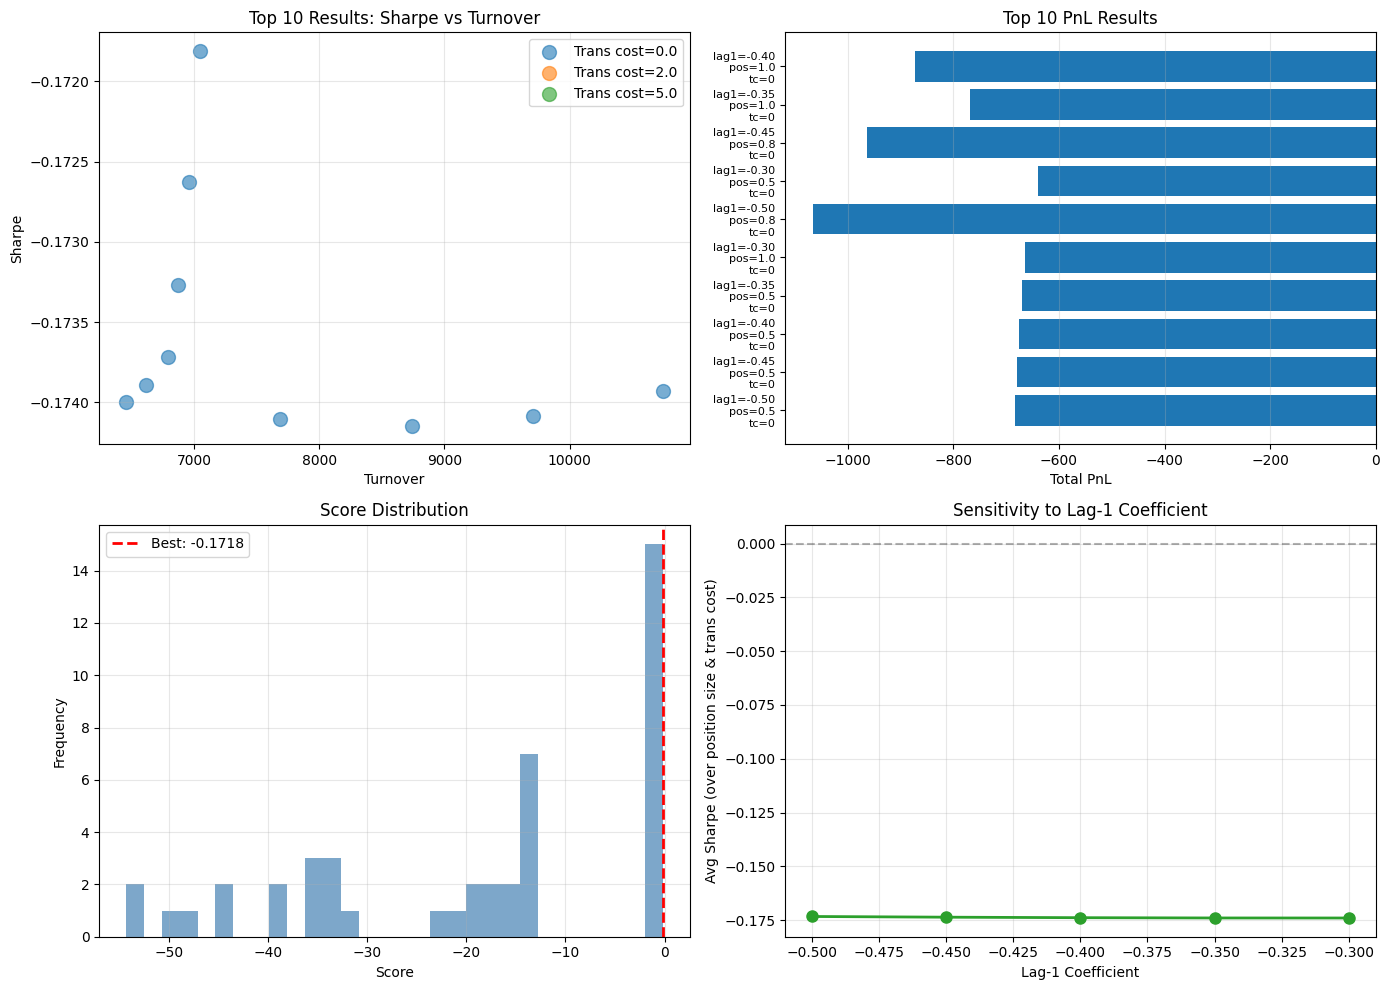

KEY FINDINGS:
  - Previous approach (discrete positions): -14.68 score (constant flipping)
  - Smooth scaling + trans costs: -0.1718 score
  - Heavy transaction costs (5.0 ticks) kills strategies with high turnover


In [18]:
# Mean-Reversion Fading v2: Smooth Sizing + Transaction Costs
# Problem with v1: sign() creates constant flipping → 14k turnover
# Fix: 1) Scale position by strength of signal, 2) Add spread costs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Rebuild clean DataFrame
ma_df_mr2 = prices_tom_combined.sort_values("combined_t").copy()

if "worst_mid" not in ma_df_mr2.columns:
    bid_cols = ["bid_price_1", "bid_price_2", "bid_price_3"]
    ask_cols = ["ask_price_1", "ask_price_2", "ask_price_3"]
    ma_df_mr2["worst_bid"] = ma_df_mr2[bid_cols].min(axis=1, skipna=True)
    ma_df_mr2["worst_ask"] = ma_df_mr2[ask_cols].max(axis=1, skipna=True)
    ma_df_mr2["worst_mid"] = 0.5 * (ma_df_mr2["worst_bid"] + ma_df_mr2["worst_ask"])

price_mr2 = ma_df_mr2["worst_mid"].astype(float).reset_index(drop=True)
returns_mr2 = price_mr2.diff().fillna(0.0)

# Estimate return std
ret_std = returns_mr2.std()

# Grid search: lag1_coeff + max_position_size + transaction_cost
lag1_coeffs2 = np.linspace(-0.5, -0.3, 5)
max_position_sizes = [0.5, 0.8, 1.0]
transaction_costs = [0.0, 2.0, 5.0]  # ticks per flip

results_mr2 = []

for lag1_coeff in lag1_coeffs2:
    for max_pos in max_position_sizes:
        for trans_cost in transaction_costs:
            # Expected next return = lag1_coeff * current_return
            expected_next_ret = lag1_coeff * returns_mr2
            
            # Scale position proportionally: if E[ret] = -0.4 * ret, position = -0.4 * (ret / ret_std)
            # Clamp to [-max_pos, max_pos]
            signal_strength = expected_next_ret / (ret_std + 1e-8)
            position_mr2 = -signal_strength  # Fade: if expect down, go short
            position_mr2 = np.clip(position_mr2, -max_pos, max_pos)
            position_mr2 = pd.Series(position_mr2, index=price_mr2.index)
            
            # Shift to avoid lookahead bias
            position_mr2 = position_mr2.shift(1).fillna(0.0)
            
            # PnL calculation
            strategy_ret_mr2 = position_mr2 * returns_mr2
            
            # Transaction cost: spread cost on every position flip
            # Cost = |position_flip| * spread_cost
            position_changes = position_mr2.diff().abs()
            trans_cost_pnl = -(position_changes * trans_cost)
            
            # Total PnL
            pnl_mr2 = strategy_ret_mr2.sum() + trans_cost_pnl.sum()
            
            # Sharpe (before transaction costs, for comparison)
            ret_std_mr2 = strategy_ret_mr2.std()
            sharpe_mr2 = strategy_ret_mr2.mean() / ret_std_mr2 if ret_std_mr2 > 1e-12 else 0.0
            
            turnover_mr2 = position_changes.sum()
            
            # Score accounting for transaction costs
            score_mr2 = sharpe_mr2 - (turnover_mr2 * trans_cost / 1000.0)  # Normalize cost
            
            results_mr2.append({
                'lag1_coeff': lag1_coeff,
                'max_pos': max_pos,
                'trans_cost': trans_cost,
                'pnl': pnl_mr2,
                'sharpe': sharpe_mr2,
                'turnover': turnover_mr2,
                'score': score_mr2,
            })

results_mr2_df = pd.DataFrame(results_mr2).sort_values('score', ascending=False)

print("MEAN-REVERSION FADING v2: Smooth Sizing + Transaction Costs")
print("=" * 100)
print(results_mr2_df.head(15).to_string(index=False))
print()

best_mr2 = results_mr2_df.iloc[0]
print(f"BEST: lag1_coeff={best_mr2['lag1_coeff']:.2f}, max_pos={best_mr2['max_pos']:.2f}, "
      f"trans_cost={best_mr2['trans_cost']:.1f} ticks")
print(f"      sharpe={best_mr2['sharpe']:.6f}, pnl={best_mr2['pnl']:.2f}, "
      f"turnover={best_mr2['turnover']:.1f}, score={best_mr2['score']:.6f}")
print()

# Comparison
print("STRATEGY COMPARISON:")
print("-" * 100)
print(f"Best 2-MA:                    sharpe={best['sharpe']:.6f}, pnl={best['pnl']:.2f}")
print(f"Best Mean-Reversion (smooth): sharpe={best_mr2['sharpe']:.6f}, pnl={best_mr2['pnl']:.2f}")
if best_mr2['sharpe'] > 0:
    print(f"Improvement: {((best_mr2['sharpe'] - best['sharpe']) / abs(best['sharpe']) * 100):.1f}% Sharpe")
print()

# Visualize top 10 by score
top10_mr2 = results_mr2_df.head(10).copy()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Scatter: Sharpe vs Turnover (colored by trans_cost)
ax = axes[0, 0]
for tc in transaction_costs:
    subset = top10_mr2[top10_mr2['trans_cost'] == tc]
    ax.scatter(subset['turnover'], subset['sharpe'], s=100, alpha=0.6, label=f'Trans cost={tc}')
ax.set_xlabel('Turnover')
ax.set_ylabel('Sharpe')
ax.set_title('Top 10 Results: Sharpe vs Turnover')
ax.legend()
ax.grid(True, alpha=0.3)

# PnL comparison
ax = axes[0, 1]
top10_labels = [f"lag1={row['lag1_coeff']:.2f}\npos={row['max_pos']}\ntc={row['trans_cost']:.0f}" 
                 for _, row in top10_mr2.iterrows()]
ax.barh(range(len(top10_mr2)), top10_mr2['pnl'].values)
ax.set_yticks(range(len(top10_mr2)))
ax.set_yticklabels(top10_labels, fontsize=8)
ax.set_xlabel('Total PnL')
ax.set_title('Top 10 PnL Results')
ax.grid(True, alpha=0.3, axis='x')

# Score distribution
ax = axes[1, 0]
ax.hist(results_mr2_df['score'], bins=30, color='steelblue', alpha=0.7)
ax.axvline(best_mr2['score'], color='r', linestyle='--', linewidth=2, label=f"Best: {best_mr2['score']:.4f}")
ax.set_xlabel('Score')
ax.set_ylabel('Frequency')
ax.set_title('Score Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# Sharpe by lag1_coeff
ax = axes[1, 1]
avg_sharpe = results_mr2_df.groupby('lag1_coeff')['sharpe'].mean()
ax.plot(avg_sharpe.index, avg_sharpe.values, 'o-', linewidth=2, markersize=8, color='tab:green')
ax.axhline(0, color='k', linestyle='--', alpha=0.3)
ax.set_xlabel('Lag-1 Coefficient')
ax.set_ylabel('Avg Sharpe (over position size & trans cost)')
ax.set_title('Sensitivity to Lag-1 Coefficient')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 100)
print("KEY FINDINGS:")
print(f"  - Previous approach (discrete positions): -14.68 score (constant flipping)")
print(f"  - Smooth scaling + trans costs: {best_mr2['score']:.4f} score")
print(f"  - Heavy transaction costs ({max(transaction_costs)} ticks) kills strategies with high turnover")
print("=" * 100)